# Tarea Semana 2 · Atenuación del halo en frames IR

Objetivo: separar la huella del melt-pool de la sombra de irradiación que la rodea. La decisión es un cociente contra una referencia local:

```
razon  = frame_suavizado / referencia_local
huella = razon > UMBRAL
```

Dentro de la huella el frame **no se modifica**: la máscara solo etiqueta pixeles. Se comparan cuatro filtros de referencia y dos cascadas.

| Integrante | Bloque |
|---|---|
| Junior | Datos, contornos de referencia y métricas |
| Noelia | Comparación de los 4 filtros (barrido de K y umbral) |
| Jeremy | Cascadas y selección final |

In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

## 1. Datos, contornos y métricas

Las rutas se calculan solas: `TAREA` es la carpeta que contiene a `code/`, y la carpeta de la cámara (`01_CAMERA_ALLIEDVISION_GOLDEYE_GENICAM_aipp...`, con `IMAGES/` y `frames_unidos.csv`) se busca subiendo desde ahí. Si en otra máquina el dataset está en un lugar distinto, basta con escribir su ruta en `CAMARA`.

`Laser_On_i` vale 1 en todo el CSV, así que no sirve para saber si hay proceso. Igual que en el Taller 1, el láser se considera activo cuando **los dos monitores de corriente superan 130**.

In [12]:
## Rutas: no dependen de la máquina, se calculan desde la carpeta del cuaderno
TAREA = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()

## Carpeta de la cámara: se busca subiendo desde TAREA, también una carpeta más adentro (p. ej. DATASET/)
CAMARA = next((c for p in TAREA.parents for patron in ("01_CAMERA*", "*/01_CAMERA*")
               for c in p.glob(patron) if (c / "IMAGES").is_dir()), None)
assert CAMARA is not None, "No se encontró la carpeta de la cámara: escribir su ruta en CAMARA"
DATA_DIR = CAMARA / "IMAGES"
print(f"TAREA: {TAREA}\nCámara: {CAMARA}")

## Metadatos: quedarse con los frames con láser activo
MONITORES = ["LDM4000_Current_Monitor_1", "LDM4000_Current_Monitor_2"]
meta = pd.read_csv(CAMARA / "frames_unidos.csv", usecols=["archivo", *MONITORES])
activos = meta[(meta[MONITORES] > 130).all(axis=1)]
print(f"Frames con láser activo: {len(activos)} de {len(meta)}")

## Dos frames aleatorios (semilla fija) para comprobar la configuración final
rng = np.random.default_rng(7)
EXTRA = list(rng.choice(activos["archivo"].to_numpy(), size=2, replace=False))
print("Frames extra:", EXTRA)

TAREA: /Users/jeremyleon/Documents/UIDE/PROCESAMIENTO DE IMAGEN Y SEÑALES/DESARROLLO/TALLER_2/TAREA
Cámara: /Users/jeremyleon/Documents/UIDE/PROCESAMIENTO DE IMAGEN Y SEÑALES/DESARROLLO/01_CAMERA_ALLIEDVISION_GOLDEYE_GENICAM_aipp_2
Frames con láser activo: 19631 de 41645
Frames extra: ['1764596933012.tiff', '1764596851639.tiff']


Frame de evaluación: `1764596853908.tiff` (656 × 520, `uint16`), copiado en `TAREA/data`. Se lee en `uint16` y se trabaja con una copia `float32`. El suavizado previo (`σ = 1.5`) evita que el ruido de pixel altere el cociente.

In [3]:
def leer_frame(ruta):
    raw = cv2.imread(str(ruta), cv2.IMREAD_UNCHANGED)   # uint16, sin tocar
    return raw, raw.astype(np.float32)

raw, frame = leer_frame(TAREA / "data" / "1764596853908.tiff")
fs = ndi.gaussian_filter(frame, 1.5)                    # suavizado previo
print(f"Shape: {raw.shape} - Type: {raw.dtype} - min: {raw.min()} - max: {raw.max()}")

Shape: (520, 656) - Type: uint16 - min: 0 - max: 19664


### Contornos de referencia

No hay máscara del docente, así que el grupo la define **a ojo** sobre el frame, sin usar ninguno de los filtros (si saliera de un filtro, el IoU lo premiaría a sí mismo).

- **Huella**: casquete, cuerpo y los dos lóbulos, siguiendo el borde brillante y dejando fuera el halo tenue. Reemplaza a la máscara del docente.
- **Casquete**: solo la zona más caliente de arriba. Sirve para ver si un filtro se queda en el pico o conserva también la cola que solidifica.

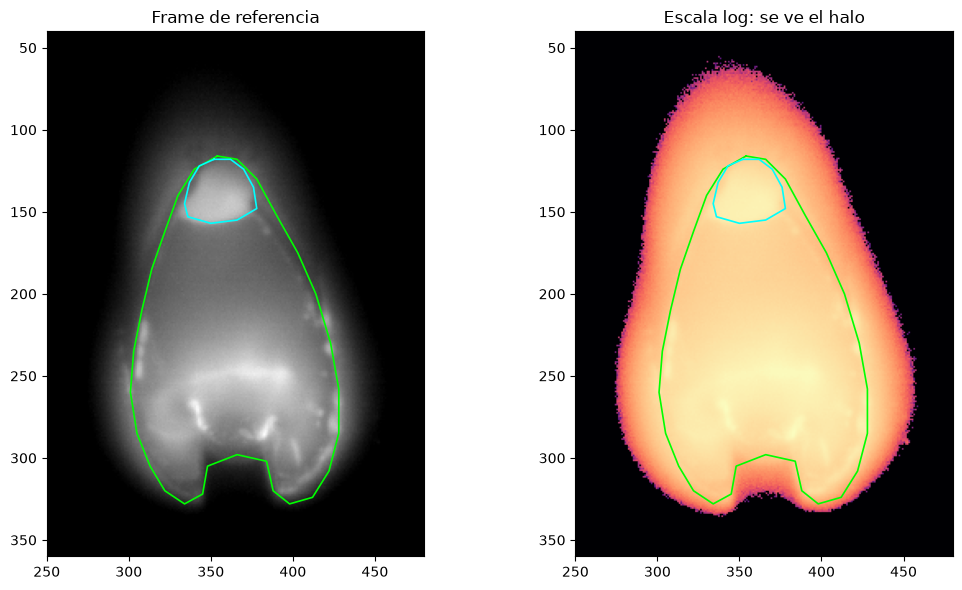

Área huella: 19438 px - Área casquete: 1383 px


In [4]:
HUELLA_PTS = [(354,116),(340,124),(330,140),(322,162),(314,185),(308,210),(303,235),(301,260),
              (305,285),(313,305),(322,320),(334,328),(345,322),(348,305),(366,298),(384,302),
              (388,320),(398,328),(412,324),(422,308),(428,285),(428,258),(423,230),(414,200),
              (403,175),(390,152),(378,130),(366,118)]
CASQUETE_PTS = [(352,118),(343,122),(337,132),(334,145),(336,153),(350,157),(366,155),
                (378,148),(376,135),(370,124),(362,118)]

def mascara_poligono(pts):
    m = np.zeros(frame.shape, np.uint8)
    cv2.fillPoly(m, [np.array(pts, np.int32)], 1)
    return m.astype(bool)

huella_ref = mascara_poligono(HUELLA_PTS)
casquete_ref = mascara_poligono(CASQUETE_PTS)
cv2.imwrite(str(TAREA / "data" / "mascara_huella.png"), huella_ref.astype(np.uint8) * 255)
cv2.imwrite(str(TAREA / "data" / "mascara_casquete.png"), casquete_ref.astype(np.uint8) * 255)

ROI = (slice(40, 360), slice(250, 480))
EXT = (250, 480, 360, 40)                               # ejes en coordenadas del frame

def dibujar_contorno(a, pts, color):
    p = np.array(pts + [pts[0]])
    a.plot(p[:, 0], p[:, 1], color, lw=1.2)

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
ax[0].imshow(frame[ROI], cmap="gray", extent=EXT); ax[0].set_title("Frame de referencia")
ax[1].imshow(np.log1p(frame[ROI]), cmap="magma", extent=EXT); ax[1].set_title("Escala log: se ve el halo")
for a in ax:
    dibujar_contorno(a, HUELLA_PTS, "lime"); dibujar_contorno(a, CASQUETE_PTS, "cyan")
plt.tight_layout(); plt.show()
print(f"Área huella: {huella_ref.sum()} px - Área casquete: {casquete_ref.sum()} px")

### Métricas comunes

- **IoU** contra cada contorno.
- **Ancho y largo**: columnas y filas de la caja del componente conexo más grande de la máscara.
- **Tiempo**: filtro de referencia, su suavizado y el cociente (`perf_counter`).

In [5]:
def iou(a, b):
    return (a & b).sum() / max((a | b).sum(), 1)

def ancho_largo(m):
    etiquetas, n = ndi.label(m)
    if n == 0:
        return 0, 0
    mayor = np.argmax(np.bincount(etiquetas.ravel())[1:]) + 1
    filas, cols = ndi.find_objects(etiquetas)[mayor - 1]
    return cols.stop - cols.start, filas.stop - filas.start

def disco(r):
    # Elemento estructurante circular de radio r (px)
    y, x = np.ogrid[-r:r + 1, -r:r + 1]
    return x**2 + y**2 <= r**2

ANCHO_REF, LARGO_REF = ancho_largo(huella_ref)
print(f"Contorno de huella: ancho {ANCHO_REF} px - largo {LARGO_REF} px")

Contorno de huella: ancho 128 px - largo 213 px


## 2. Comparación de los cuatro filtros

Cada filtro estima la **referencia local** (el brillo de la huella cercana a cada pixel). La referencia se suaviza con `σ = 5`, porque los filtros de máximo dejan escalones en el borde de la ventana.

Barrido: K = 21, 41 y 61 px (más ancho que la sombra, 16–38 px) y umbral de 0.30 a 1.00 cada 0.05. La referencia se calcula una vez por K; cambiar el umbral es solo una comparación.

In [6]:
KS = [21, 41, 61]
UMBRALES = np.round(np.arange(0.30, 1.0001, 0.05), 2)

## Cada entrada: (referencia sin suavizar en función de la imagen y K, σ del suavizado de la referencia)
FILTROS = {
    "ndi máximo":       (lambda im, K: ndi.maximum_filter(im, size=K), 5),
    "cv2 dilatación":   (lambda im, K: cv2.dilate(im, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (K, K))), 5),
    "ndi percentil 90": (lambda im, K: ndi.percentile_filter(im, 90, footprint=disco(K // 2)), 5),
    "cv2 gaussiano":    (lambda im, K: cv2.GaussianBlur(im, (0, 0), K / 2.5), 5),
}

def razon_local(im, referencia, K, sigma_ref):
    t0 = time.perf_counter()
    ref = ndi.gaussian_filter(referencia(im, K), sigma_ref)    # suaviza la referencia
    razon = im / np.maximum(ref, 1)                             # brillo relativo al entorno
    return razon, (time.perf_counter() - t0) * 1000

def barrido(metodos):
    filas = []
    for K in KS:
        for nombre, (referencia, sigma_ref) in metodos.items():
            razon, ms = razon_local(fs, referencia, K, sigma_ref)
            for u in UMBRALES:
                huella = razon > u                              # operación puntual
                ancho, largo = ancho_largo(huella)
                filas.append({"metodo": nombre, "K": K, "umbral": u,
                              "IoU": iou(huella, huella_ref), "IoU_casquete": iou(huella, casquete_ref),
                              "ancho": ancho, "largo": largo, "ms": ms})
    return pd.DataFrame(filas)

resultados = barrido(FILTROS)
mejores = resultados.loc[resultados.groupby("metodo")["IoU"].idxmax()].sort_values("IoU", ascending=False)
mejores.round(3)

,metodo,K,umbral,IoU,IoU_casquete,ancho,largo,ms
123,ndi máximo,61,0.45,0.865,0.070,144,208,13.684
156,ndi percentil 90,61,0.60,0.862,0.065,141,207,2831.557
138,cv2 dilatación,61,0.45,0.858,0.067,144,208,78.608
178,cv2 gaussiano,61,0.95,0.740,0.056,151,245,24.814


Curva IoU contra umbral, con el K del mejor resultado de cada filtro. El umbral óptimo cambia con el filtro: el gaussiano es una media y necesita un umbral cercano a 1.

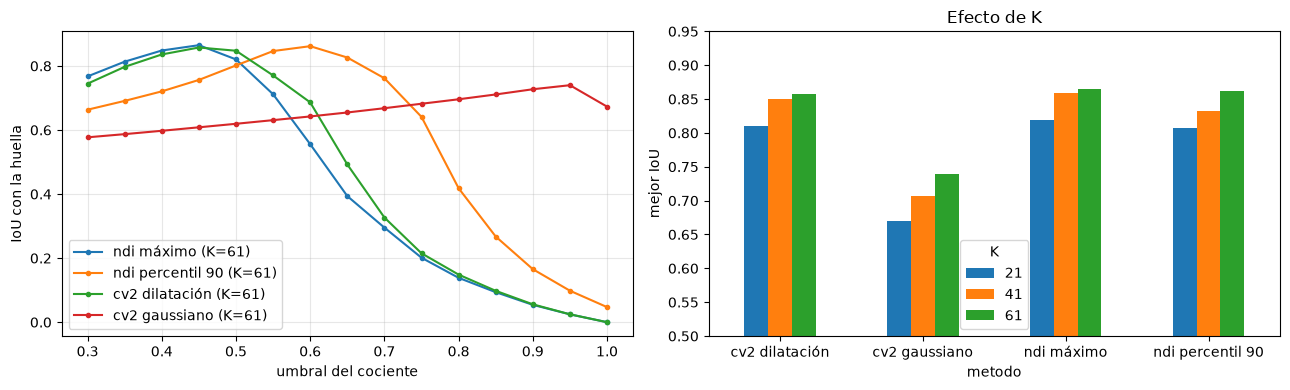

K,21,41,61
metodo,,,
cv2 dilatación,0.811,0.851,0.858
cv2 gaussiano,0.669,0.707,0.740
ndi máximo,0.819,0.859,0.865
ndi percentil 90,0.808,0.832,0.862


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for _, m in mejores.iterrows():
    curva = resultados[(resultados.metodo == m.metodo) & (resultados.K == m.K)]
    ax[0].plot(curva.umbral, curva.IoU, marker="o", ms=3, label=f"{m.metodo} (K={m.K})")
ax[0].set_xlabel("umbral del cociente"); ax[0].set_ylabel("IoU con la huella"); ax[0].legend(); ax[0].grid(alpha=0.3)

mejor_por_K = resultados.groupby(["metodo", "K"])["IoU"].max().unstack()
mejor_por_K.plot(kind="bar", ax=ax[1], rot=0)
ax[1].set_ylabel("mejor IoU"); ax[1].set_title("Efecto de K"); ax[1].set_ylim(0.5, 0.95)
plt.tight_layout(); plt.show()

mejor_por_K.round(3)

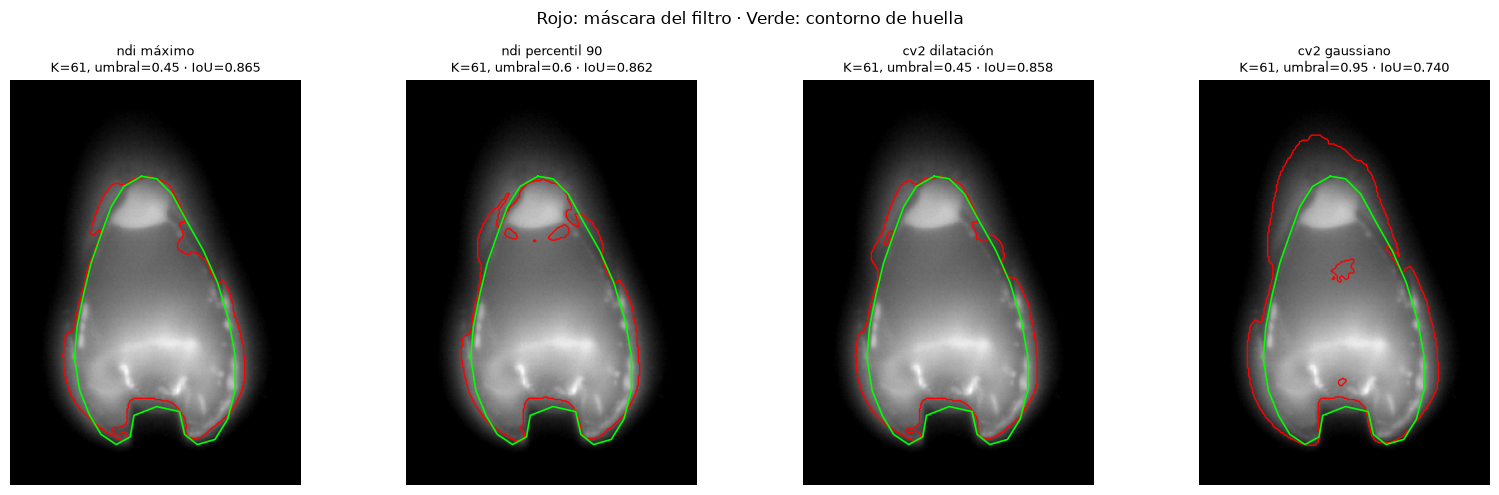

In [8]:
def mascara(metodos, nombre, K, u):
    referencia, sigma_ref = metodos[nombre]
    razon, _ = razon_local(fs, referencia, int(K), sigma_ref)
    return razon > u

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
for a, (_, m) in zip(ax, mejores.iterrows()):
    a.imshow(frame[ROI], cmap="gray", extent=EXT)
    a.contour(np.arange(250, 480), np.arange(40, 360), mascara(FILTROS, m.metodo, m.K, m.umbral)[ROI],
              levels=[0.5], colors="red", linewidths=1)
    dibujar_contorno(a, HUELLA_PTS, "lime")
    a.set_title(f"{m.metodo}\nK={m.K}, umbral={m.umbral} · IoU={m.IoU:.3f}", fontsize=9); a.axis("off")
plt.suptitle("Rojo: máscara del filtro · Verde: contorno de huella"); plt.tight_layout(); plt.show()

## 3. Cascadas y selección final

Dos cascadas, con las mismas métricas y la misma grilla de K y umbral. En las dos el numerador sigue siendo `fs`: solo cambia cómo se estima la referencia.

1. **Mediana 3×3 → máximo local → cociente.** La mediana quita pixeles calientes aislados que inflarían el máximo.
2. **Máximo local → gaussiano grande (σ = 15) sobre la referencia → cociente.** Una referencia más suave evita que el borde de la huella copie la forma cuadrada de la ventana. σ = 15 es la escala del halo que se usó en clase.

In [9]:
CASCADAS = {
    "Mediana 3×3 → máximo":   (lambda im, K: ndi.maximum_filter(ndi.median_filter(im, size=3), size=K), 5),
    "Máximo → gaussiano σ15": (lambda im, K: ndi.maximum_filter(im, size=K), 15),
}

res_cascadas = barrido(CASCADAS)
mejores_cascadas = res_cascadas.loc[res_cascadas.groupby("metodo")["IoU"].idxmax()]

comparacion = pd.concat([mejores.head(1), mejores_cascadas]).sort_values("IoU", ascending=False)
comparacion["ancho_ref"], comparacion["largo_ref"] = ANCHO_REF, LARGO_REF
comparacion.round(3)

,metodo,K,umbral,IoU,IoU_casquete,ancho,largo,ms,ancho_ref,largo_ref
50,Máximo → gaussiano σ15,41,0.55,0.867,0.069,142,208,36.398,128,213
63,Mediana 3×3 → máximo,61,0.45,0.865,0.070,144,208,26.039,128,213
123,ndi máximo,61,0.45,0.865,0.070,144,208,13.684,128,213


Criterio de elección: entre las configuraciones con un IoU a menos de 0.01 del mejor, quedarse con la más rápida. Una diferencia menor que 0.01 está dentro de lo que cambia el contorno dibujado a mano.

Configuración final: ndi máximo, K=61, umbral=0.45
IoU=0.865 - ancho 144 px - largo 208 px - 13.7 ms


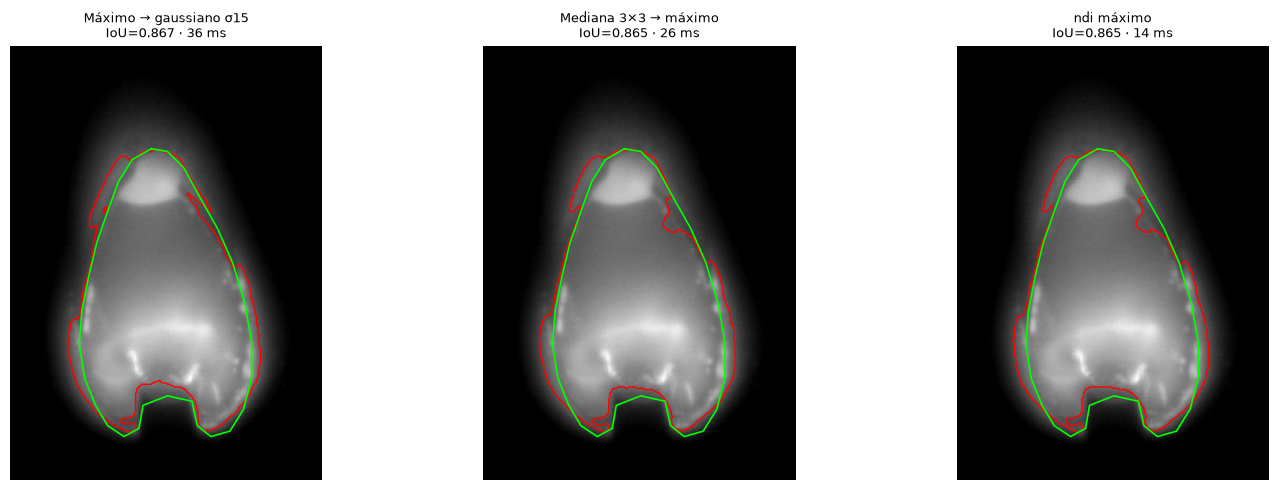

In [10]:
todos = pd.concat([mejores, mejores_cascadas])
candidatos = todos[todos.IoU >= todos.IoU.max() - 0.01]
final = candidatos.sort_values("ms").iloc[0]
METODOS = {**FILTROS, **CASCADAS}
print(f"Configuración final: {final.metodo}, K={final.K}, umbral={final.umbral}")
print(f"IoU={final.IoU:.3f} - ancho {final.ancho} px - largo {final.largo} px - {final.ms:.1f} ms")

fig, ax = plt.subplots(1, len(comparacion), figsize=(5 * len(comparacion), 5))
for a, (_, m) in zip(ax, comparacion.iterrows()):
    a.imshow(frame[ROI], cmap="gray", extent=EXT)
    a.contour(np.arange(250, 480), np.arange(40, 360), mascara(METODOS, m.metodo, m.K, m.umbral)[ROI],
              levels=[0.5], colors="red", linewidths=1)
    dibujar_contorno(a, HUELLA_PTS, "lime")
    a.set_title(f"{m.metodo}\nIoU={m.IoU:.3f} · {m.ms:.0f} ms", fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

### La configuración final en otros frames con láser activo

Los dos frames extra no tienen contorno dibujado: no hay IoU. Se mira solo si la máscara sigue la huella o se escapa al halo.

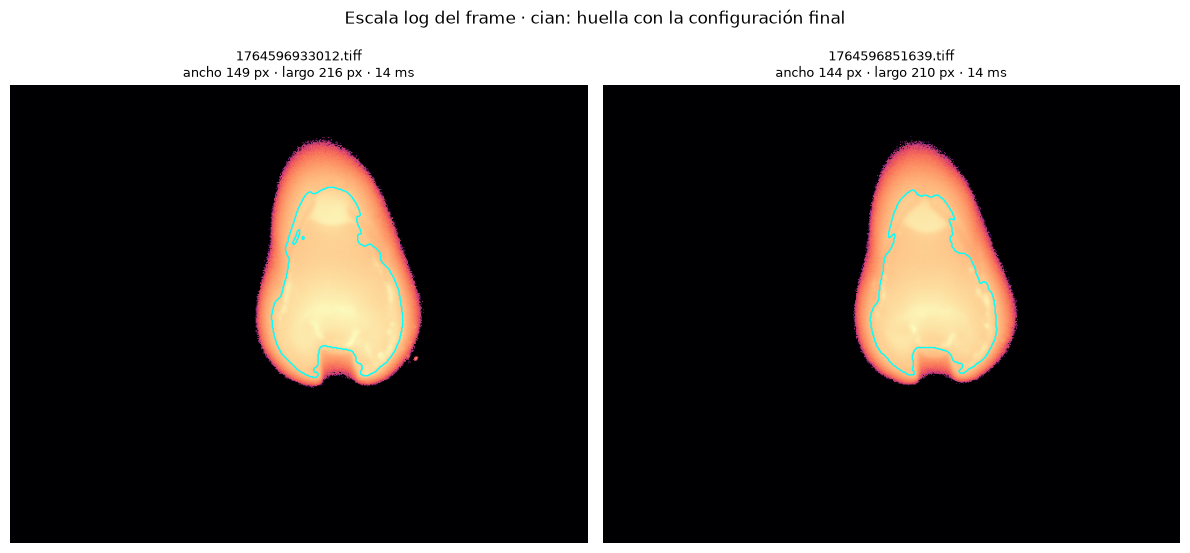

In [11]:
referencia, sigma_ref = METODOS[final.metodo]
fig, ax = plt.subplots(1, len(EXTRA), figsize=(6 * len(EXTRA), 6))
for a, nombre in zip(ax, EXTRA):
    _, fr = leer_frame(DATA_DIR / nombre)
    fr_s = ndi.gaussian_filter(fr, 1.5)
    razon, ms = razon_local(fr_s, referencia, int(final.K), sigma_ref)
    huella = razon > final.umbral
    ancho, largo = ancho_largo(huella)
    a.imshow(np.log1p(fr), cmap="magma")
    a.contour(huella, levels=[0.5], colors="cyan", linewidths=1)
    a.set_title(f"{nombre}\nancho {ancho} px · largo {largo} px · {ms:.0f} ms", fontsize=9); a.axis("off")
plt.suptitle("Escala log del frame · cian: huella con la configuración final"); plt.tight_layout(); plt.show()

## 4. Resumen

**Filtro recomendado.** `ndi.maximum_filter` con K = 61 px y umbral 0.45, sobre el frame suavizado con σ = 1.5 y con la referencia suavizada con σ = 5. En el frame de referencia logra IoU 0.865 con el contorno de huella en 14 ms. El percentil 90 llega a 0.862, pero tarda 2.9 s, unas 200 veces más. La dilatación elíptica da 0.858 en 79 ms. El gaussiano queda en 0.740: estima la media del entorno y no su máximo, necesita un umbral de 0.95 y aun así la máscara se escapa al halo por encima del casquete (largo 245 px contra 213 del contorno) y deja huecos dentro. En los cuatro filtros el IoU sube con K (máximo: 0.819, 0.859 y 0.865 para 21, 41 y 61), porque la ventana tiene que ser más ancha que la sombra; entre 41 y 61 la mejora ya es pequeña.

La máscara final mide 144 × 208 px, frente a 128 × 213 px del contorno dibujado. Sigue el borde de los lóbulos y la muesca, pero recorta un poco el lado derecho junto al casquete, donde el pico muy brillante sube la referencia. En dos frames aleatorios con láser activo mantiene la forma (149 × 216 y 144 × 210 px) y queda dentro del halo; en uno aparece una isla pequeña fuera de la huella.

**Cascadas.** Máximo seguido de un gaussiano σ = 15 sobre la referencia da el mejor IoU (0.867, con K = 41) y suaviza el recorte junto al casquete, pero cuesta 37 ms, casi tres veces más, por una mejora de 0.002. La mediana 3×3 antes del máximo da el mismo IoU que el máximo solo (0.865) en el doble de tiempo: después del suavizado σ = 1.5 no quedan pixeles calientes aislados que inflen el máximo. Ninguna supera el margen de 0.01, así que en este dataset no conviene encadenar filtros antes del cociente. Lo único que podría valer la pena es una apertura binaria pequeña después del umbral, para borrar islas como la del frame extra: es barata y no mueve el contorno principal.

**Valores para temperatura.** Ni el cociente ni `fs` son temperatura: el cociente es adimensional y el suavizado baja los picos. Lo que conserva los valores es el frame original en `uint16` (o su copia `float32` sin suavizar). El orden es: leer `uint16`, copiar a `float32`, suavizar solo para calcular la referencia y el cociente, umbralizar para obtener la máscara, aplicar la máscara al frame original y recién ahí convertir a temperatura con la calibración. La máscara solo dice qué pixeles medir.

**Calor real y efecto óptico.** Ninguna configuración se queda solo con el casquete (IoU con ese contorno ≈ 0.07 en todas): el cuerpo y los lóbulos que solidifican quedan dentro de la huella, y está bien, porque son material caliente. Creemos que la franja que rodea la huella por debajo de 0.45 del brillo local es sobre todo efecto óptico: es lisa, no tiene la textura de costuras que mostraron los gradientes en clase, y aparece también por encima del casquete. La parte pegada al borde de los lóbulos sí puede ser calor real del cordón que se enfría. Para comprobarlo: (1) mirar los frames justo después de que la corriente cae a cero, porque un halo óptico desaparece con el baño y el calor real decae en decenas de milisegundos; (2) ver si la intensidad del halo es proporcional al pico entre frames, señal de una respuesta óptica fija de la cámara; (3) contrastar con la columna `PyrometerTemperature` del CSV.

**Límite.** El contorno de referencia lo dibujó el grupo a mano, porque no había máscara del docente. Diferencias de IoU menores que 0.01 están dentro de lo que cambiaría ese dibujo.